# 02 — Model Training & Comparison
Train 6 classifiers on road condition sensor data, compare metrics, visualise results.

In [1]:
import sqlite3, os, json, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import dump, load
warnings.filterwarnings('ignore')

DB_PATH   = os.path.join('..', 'road_data.db')
MODEL_DIR = os.path.join('models')
os.makedirs(MODEL_DIR, exist_ok=True)

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing   import StandardScaler, LabelEncoder
from sklearn.metrics         import (accuracy_score, precision_score, recall_score,
                                     f1_score, confusion_matrix, classification_report,
                                     roc_auc_score, ConfusionMatrixDisplay)
from sklearn.linear_model    import LogisticRegression
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm             import SVC
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.neural_network  import MLPClassifier
from xgboost                 import XGBClassifier

COLORS = {'good':'#1a6','avg':'#ca0','bad':'#c33'}
print("Imports OK")


Imports OK


## Load & Engineer Features

In [2]:
con = sqlite3.connect(DB_PATH)
df  = pd.read_sql_query("""
    SELECT condition, speed, accel_x, accel_y, accel_z, accel_magnitude,
           gyro_x, gyro_y, gyro_z, gyro_magnitude,
           accuracy, altitude, heading
    FROM readings WHERE condition IN ('good','avg','bad')
""", con)
con.close()
print(f"Loaded {len(df)} rows | {df['condition'].value_counts().to_dict()}")

# ── Feature engineering ──────────────────────────────────────
df['accel_xy']     = np.sqrt(df.accel_x**2 + df.accel_y**2)
df['accel_xz']     = np.sqrt(df.accel_x**2 + df.accel_z**2)
df['accel_yz']     = np.sqrt(df.accel_y**2 + df.accel_z**2)
df['accel_norm_z'] = df.accel_z.abs() / (df.accel_magnitude + 1e-6)
df['gyro_xy']      = np.sqrt(df.gyro_x**2 + df.gyro_y**2)
df['gyro_total_turn'] = df.gyro_magnitude
df['speed_kmh']    = df.speed.fillna(0) * 3.6
df['speed_bucket'] = pd.cut(df.speed_kmh, bins=[-1,10,30,60,999], labels=[0,1,2,3]).astype(float)
df['rough_proxy']  = df.accel_magnitude / (df.speed_kmh + 1)
heading_rad        = np.deg2rad(df.heading.fillna(0))
df['heading_sin']  = np.sin(heading_rad)
df['heading_cos']  = np.cos(heading_rad)

FEATURE_COLS = [
    'speed','accel_x','accel_y','accel_z','accel_magnitude',
    'gyro_x','gyro_y','gyro_z','gyro_magnitude',
    'accuracy','altitude',
    'accel_xy','accel_xz','accel_yz','accel_norm_z',
    'gyro_xy','gyro_total_turn',
    'speed_kmh','speed_bucket','rough_proxy',
    'heading_sin','heading_cos'
]

df = df.dropna(subset=FEATURE_COLS, thresh=len(FEATURE_COLS)-3)
df[FEATURE_COLS] = df[FEATURE_COLS].fillna(df[FEATURE_COLS].median())

X   = df[FEATURE_COLS].values
le  = LabelEncoder()
y   = le.fit_transform(df['condition'].values)
print(f"Classes: {le.classes_} | Features: {len(FEATURE_COLS)}")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler    = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

dump(scaler, os.path.join(MODEL_DIR,'scaler.pkl'))
dump(le,     os.path.join(MODEL_DIR,'label_encoder.pkl'))
with open(os.path.join(MODEL_DIR,'feature_cols.json'),'w') as f:
    json.dump(FEATURE_COLS, f)
print(f"Train: {len(X_train)} | Test: {len(X_test)}")


Loaded 1948 rows | {'avg': 711, 'good': 693, 'bad': 544}
Classes: ['avg' 'bad' 'good'] | Features: 22
Train: 1558 | Test: 390


## Define Models

In [3]:
models = {
    'Logistic Regression': (LogisticRegression(max_iter=1000, random_state=42), True),
    'Random Forest':       (RandomForestClassifier(n_estimators=200, random_state=42), False),
    'XGBoost':             (XGBClassifier(n_estimators=200, use_label_encoder=False,
                                          eval_metric='mlogloss', random_state=42, verbosity=0), False),
    'SVM (RBF)':           (SVC(kernel='rbf', probability=True, random_state=42), True),
    'KNN':                 (KNeighborsClassifier(n_neighbors=7), True),
    'MLP':                 (MLPClassifier(hidden_layer_sizes=(128,64), max_iter=500, random_state=42), True),
}
# (model_object, needs_scaling)
print("Models defined:", list(models.keys()))


Models defined: ['Logistic Regression', 'Random Forest', 'XGBoost', 'SVM (RBF)', 'KNN', 'MLP']


## Train All Models + 5-Fold CV

In [4]:
cv      = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = []

for name, (model, needs_scale) in models.items():
    Xtr = X_train_s if needs_scale else X_train
    Xte = X_test_s  if needs_scale else X_test

    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    t0 = time.time()
    y_pred = model.predict(Xte)
    infer_ms = (time.time()-t0)/len(Xte)*1000

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    try:
        y_prob = model.predict_proba(Xte)
        auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    except:
        auc = float('nan')

    cv_res  = cross_validate(model, Xtr, y_train, cv=cv, scoring='f1_weighted')
    cv_mean = cv_res['test_score'].mean()
    cv_std  = cv_res['test_score'].std()

    feat_imp = None
    if hasattr(model, 'feature_importances_'):
        feat_imp = dict(zip(FEATURE_COLS, model.feature_importances_))

    results.append({
        'model': name, 'accuracy': acc, 'precision_w': prec, 'recall_w': rec,
        'f1_weighted': f1, 'roc_auc': auc, 'cv_f1_mean': cv_mean, 'cv_f1_std': cv_std,
        'train_time_s': train_time, 'infer_time_ms': infer_ms,
        'confusion_matrix': confusion_matrix(y_test, y_pred).tolist(),
        'y_pred': y_pred.tolist(), 'y_prob': y_prob.tolist() if hasattr(model,'predict_proba') else None,
        'feat_imp': feat_imp, 'needs_scale': needs_scale,
        'class_report': classification_report(y_test, y_pred,
                                               target_names=le.classes_, output_dict=True)
    })

    dump(model, os.path.join(MODEL_DIR,
         name.replace(' ','_').replace('(','').replace(')','') + '.pkl'))
    print(f"[✓] {name:<25} acc={acc:.4f}  f1={f1:.4f}  auc={auc:.4f}  "
          f"cv={cv_mean:.4f}±{cv_std:.4f}  train={train_time:.2f}s  infer={infer_ms:.4f}ms")

print('\nAll models trained.')


[✓] Logistic Regression       acc=0.6769  f1=0.6769  auc=0.8551  cv=0.6767±0.0262  train=0.01s  infer=0.0005ms
[✓] Random Forest             acc=0.9462  f1=0.9463  auc=0.9961  cv=0.9204±0.0244  train=0.53s  infer=0.0250ms
[✓] XGBoost                   acc=0.9744  f1=0.9743  auc=0.9991  cv=0.9512±0.0090  train=0.90s  infer=0.0039ms
[✓] SVM (RBF)                 acc=0.7538  f1=0.7558  auc=0.8985  cv=0.7288±0.0345  train=0.21s  infer=0.0334ms
[✓] KNN                       acc=0.7231  f1=0.7253  auc=0.8977  cv=0.7278±0.0271  train=0.00s  infer=0.1290ms
[✓] MLP                       acc=0.8487  f1=0.8488  auc=0.9507  cv=0.8345±0.0190  train=1.84s  infer=0.0031ms

All models trained.


## Comparison Table

In [5]:
df_res = pd.DataFrame([{
    'Model': r['model'],
    'Accuracy': round(r['accuracy'],4),
    'Precision': round(r['precision_w'],4),
    'Recall': round(r['recall_w'],4),
    'F1 (weighted)': round(r['f1_weighted'],4),
    'ROC-AUC': round(r['roc_auc'],4) if not (isinstance(r['roc_auc'],float) and np.isnan(r['roc_auc'])) else 'N/A',
    'CV F1 Mean': round(r['cv_f1_mean'],4),
    'CV F1 Std': round(r['cv_f1_std'],4),
    'Train (s)': round(r['train_time_s'],3),
    'Infer (ms/pt)': round(r['infer_time_ms'],4),
} for r in results])

df_res = df_res.sort_values('F1 (weighted)', ascending=False).reset_index(drop=True)
df_res.to_csv('../ml/model_comparison.csv', index=False)
print(df_res.to_string(index=False))


              Model  Accuracy  Precision  Recall  F1 (weighted)  ROC-AUC  CV F1 Mean  CV F1 Std  Train (s)  Infer (ms/pt)
            XGBoost    0.9744     0.9746  0.9744         0.9743   0.9991      0.9512     0.0090      0.898         0.0039
      Random Forest    0.9462     0.9467  0.9462         0.9463   0.9961      0.9204     0.0244      0.525         0.0250
                MLP    0.8487     0.8489  0.8487         0.8488   0.9507      0.8345     0.0190      1.836         0.0031
          SVM (RBF)    0.7538     0.7778  0.7538         0.7558   0.8985      0.7288     0.0345      0.205         0.0334
                KNN    0.7231     0.7329  0.7231         0.7253   0.8977      0.7278     0.0271      0.000         0.1290
Logistic Regression    0.6769     0.6785  0.6769         0.6769   0.8551      0.6767     0.0262      0.012         0.0005


## Bar Chart — F1 & Accuracy Comparison

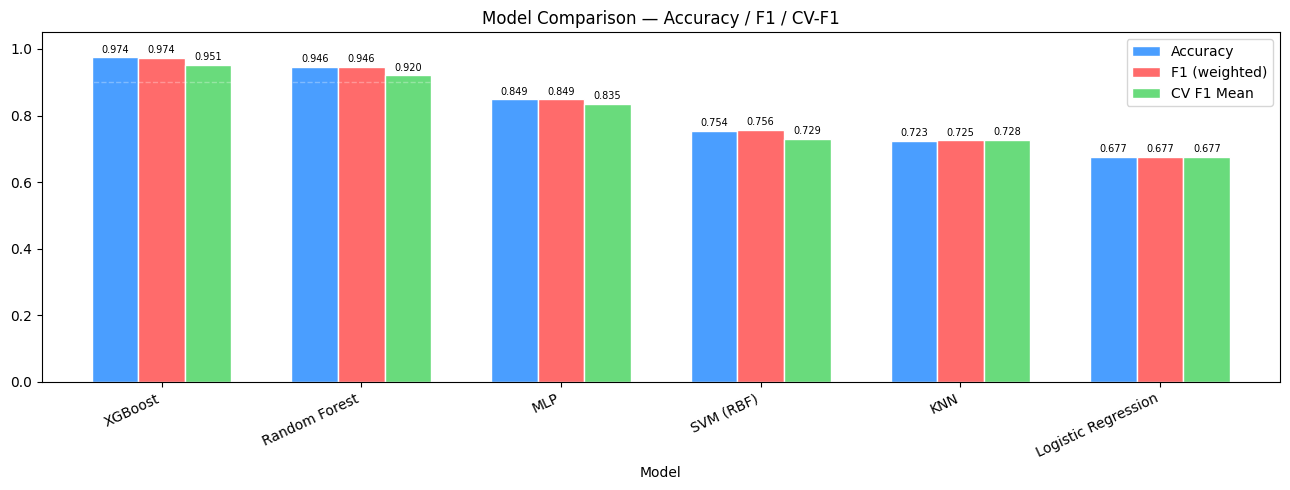

In [6]:
df_plot = df_res.set_index('Model')[['Accuracy','F1 (weighted)','CV F1 Mean']].astype(float)

ax = df_plot.plot(kind='bar', figsize=(13, 5), edgecolor='white',
                  color=['#4a9eff','#ff6b6b','#69db7c'], width=0.7)
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.set_ylim(0, 1.05)
ax.set_title('Model Comparison — Accuracy / F1 / CV-F1')
ax.axhline(0.9, color='white', linestyle='--', alpha=0.3, linewidth=1)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=7, padding=2)
plt.tight_layout()
plt.savefig('../ml/comparison_bar.png', dpi=150)
plt.show()


## Confusion Matrices — All Models

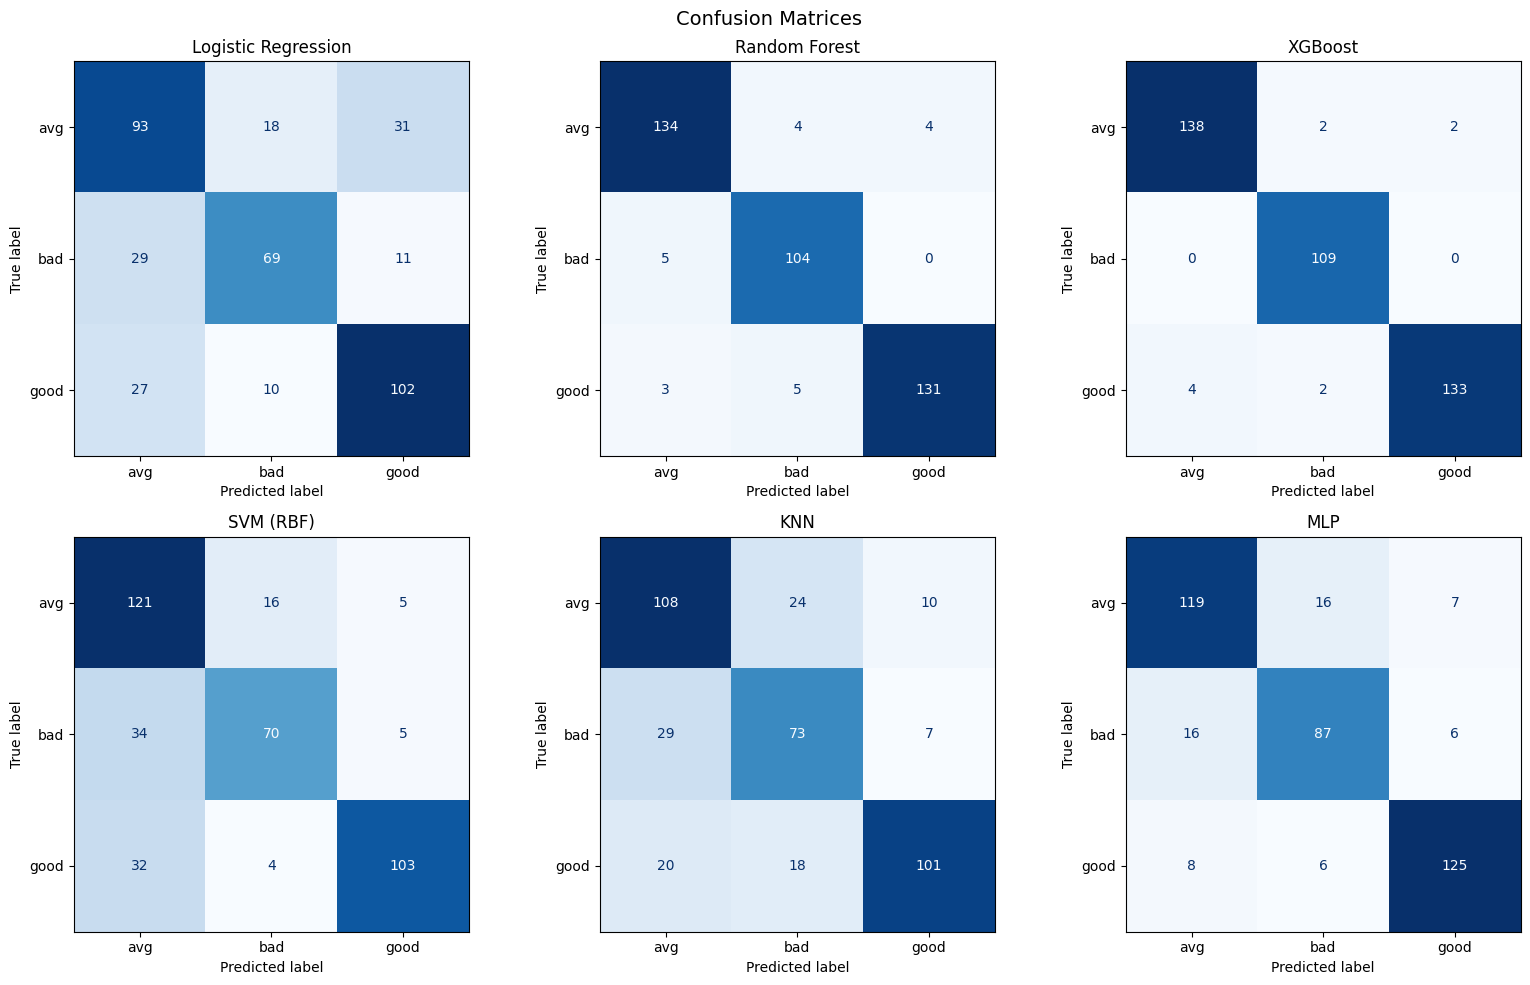

In [7]:
n = len(results)
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, r in enumerate(results):
    cm = np.array(r['confusion_matrix'])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(r['model'])

plt.suptitle('Confusion Matrices', fontsize=14)
plt.tight_layout()
plt.savefig('../ml/confusion_matrices.png', dpi=150)
plt.show()


## Feature Importance (Random Forest & XGBoost)

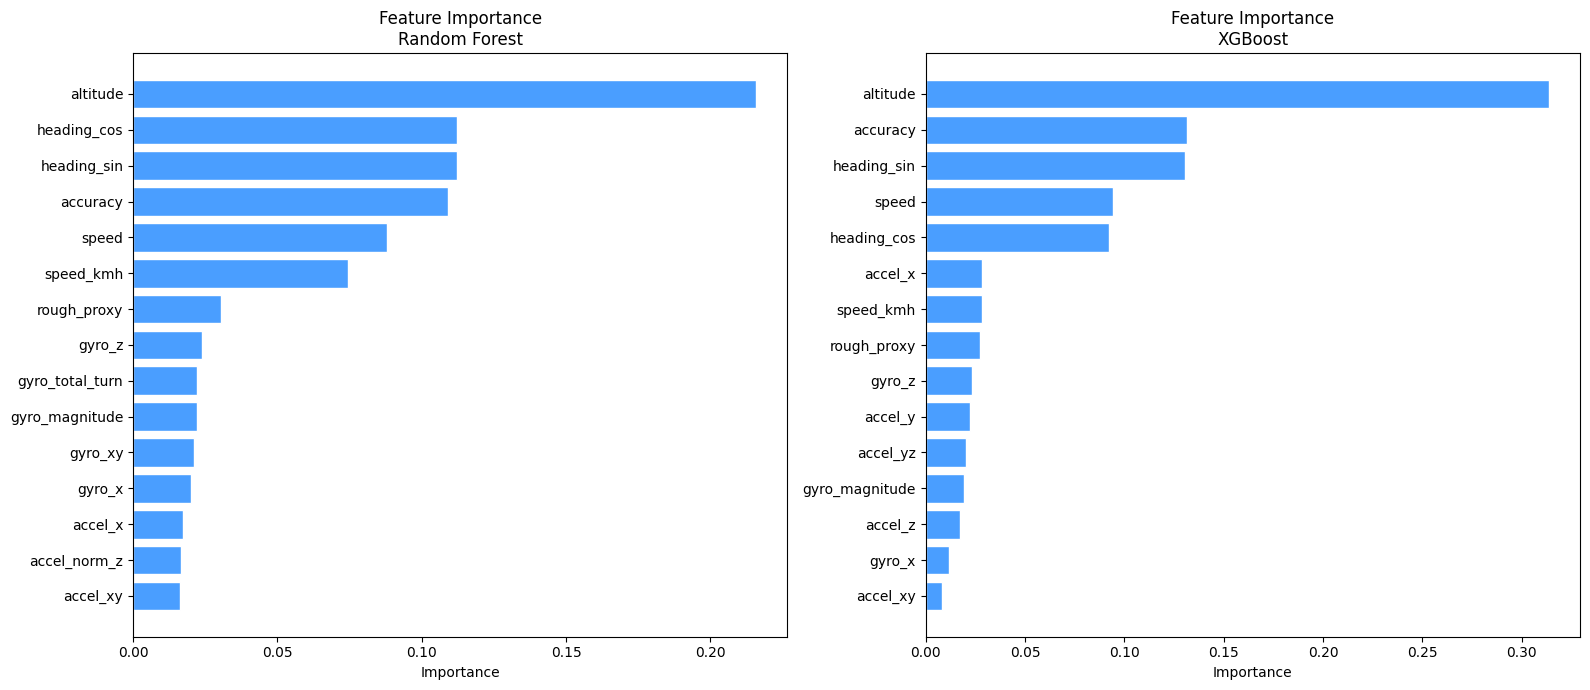

In [8]:
tree_models = [r for r in results if r['feat_imp'] is not None]

fig, axes = plt.subplots(1, len(tree_models), figsize=(16, 7))
if len(tree_models)==1: axes=[axes]

for ax, r in zip(axes, tree_models):
    fi   = pd.Series(r['feat_imp']).sort_values(ascending=True).tail(15)
    colors_bar = ['#4a9eff'] * len(fi)
    ax.barh(fi.index, fi.values, color=colors_bar, edgecolor='white')
    ax.set_title(f"Feature Importance\n{r['model']}")
    ax.set_xlabel('Importance')

plt.tight_layout()
plt.savefig('../ml/feature_importance.png', dpi=150)
plt.show()


## Per-Class F1 Heatmap

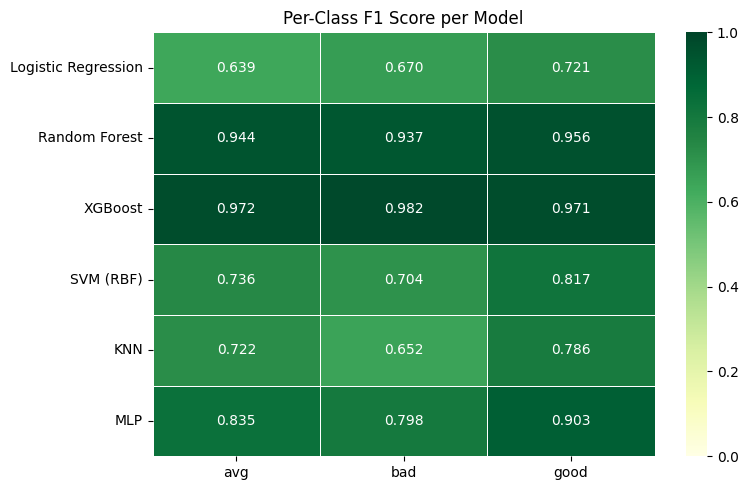

                       avg    bad   good
Logistic Regression  0.639  0.670  0.721
Random Forest        0.944  0.937  0.956
XGBoost              0.972  0.982  0.971
SVM (RBF)            0.736  0.704  0.817
KNN                  0.722  0.652  0.786
MLP                  0.835  0.798  0.903


In [9]:
class_f1 = {}
for r in results:
    row = {}
    for cls in le.classes_:
        row[cls] = round(r['class_report'].get(cls, {}).get('f1-score', 0), 3)
    class_f1[r['model']] = row

df_cf1 = pd.DataFrame(class_f1).T
plt.figure(figsize=(8,5))
sns.heatmap(df_cf1.astype(float), annot=True, fmt='.3f', cmap='YlGn',
            linewidths=0.5, vmin=0, vmax=1)
plt.title('Per-Class F1 Score per Model')
plt.tight_layout()
plt.savefig('../ml/per_class_f1.png', dpi=150)
plt.show()
print(df_cf1.to_string())


## Inference Time vs Accuracy (Trade-off)

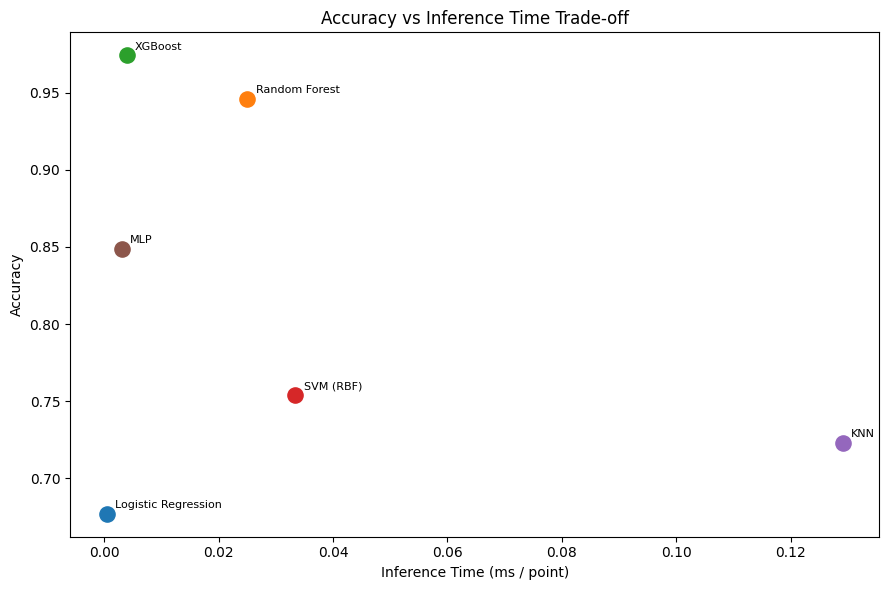

In [10]:
fig, ax = plt.subplots(figsize=(9,6))
for r in results:
    ax.scatter(r['infer_time_ms'], r['accuracy'], s=120, zorder=5)
    ax.annotate(r['model'], (r['infer_time_ms'], r['accuracy']),
                textcoords='offset points', xytext=(6,4), fontsize=8)
ax.set_xlabel('Inference Time (ms / point)')
ax.set_ylabel('Accuracy')
ax.set_title('Accuracy vs Inference Time Trade-off')
plt.tight_layout()
plt.savefig('../ml/tradeoff_plot.png', dpi=150)
plt.show()


## Select & Save Best Model

In [11]:
best    = max(results, key=lambda r: r['f1_weighted'])
print(f"★  Best model: {best['model']}")
print(f"   Accuracy  : {best['accuracy']:.4f}")
print(f"   F1-W      : {best['f1_weighted']:.4f}")
print(f"   ROC-AUC   : {best['roc_auc']:.4f}")
print(f"   CV F1     : {best['cv_f1_mean']:.4f} ± {best['cv_f1_std']:.4f}")
print(f"   Infer     : {best['infer_time_ms']:.4f} ms/pt")

with open(os.path.join(MODEL_DIR,'best_model.txt'),'w') as f:
    f.write(best['model'])

# Save full results JSON
full = [{k:v for k,v in r.items() if k not in ('y_pred','y_prob')} for r in results]
with open('../ml/model_results.json','w') as f:
    json.dump(full, f, indent=2)

print(f"\nBest model name saved → models/best_model.txt")
print(f"Full results        saved → ml/model_results.json")
print(f"Comparison CSV      saved → ml/model_comparison.csv")


★  Best model: XGBoost
   Accuracy  : 0.9744
   F1-W      : 0.9743
   ROC-AUC   : 0.9991
   CV F1     : 0.9512 ± 0.0090
   Infer     : 0.0039 ms/pt


TypeError: Object of type float32 is not JSON serializable

## Full Classification Report — Best Model

In [ ]:
print(f"=== {best['model']} ===\n")
print(classification_report(
    y_test,
    np.array(best['y_pred']),
    target_names=le.classes_
))
